In [ ]:
import shap
%matplotlib inline 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from scipy.stats import chi2_contingency
from sklearn.metrics import accuracy_score, f1_score  # ← FIXED: added f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold  # ← FIXED: was missing
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)
from imblearn.over_sampling import SMOTE 
from imblearn.pipeline import Pipeline as ImbPipeline

In [73]:
df = pd.read_csv("waze_dataset.csv")
df.head(10)

df.info()

missing_labels_df = df[df['label'].isna()].copy()
clean_df = df[df['label'].notna()].copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [74]:
# compare missing vs clean label users for unusual behaviour
print(f"Missing label users : {len(missing_labels_df)}")
print(f"Clean users : {len(clean_df)}\n")

print("Average Kilometers Driven Comparison")
print(f"Missing Users: {missing_labels_df['driven_km_drives'].mean():.2f} km")
print(f"Clean Users: {clean_df['driven_km_drives'].mean():.2f} km\n")

print("Device Distribution (%)")
missing_dist = missing_labels_df['device'].value_counts(normalize=True) * 100
clean_dist = clean_df['device'].value_counts(normalize=True) * 100

print("MISSING USERS:\n", missing_dist.round(2).astype(str) + '%')
print("\nCLEAN USERS:\n", clean_dist.round(2).astype(str) + '%')

Missing label users : 700
Clean users : 14299

Average Kilometers Driven Comparison
Missing Users: 3935.97 km
Clean Users: 4044.40 km

Device Distribution (%)
MISSING USERS:
 device
iPhone     63.86%
Android    36.14%
Name: proportion, dtype: object

CLEAN USERS:
 device
iPhone     64.52%
Android    35.48%
Name: proportion, dtype: object


In [75]:
# save 700 label users with missing labels for self-training
unlabeled_users = df[df['label'].isna()].copy()

unlabeled_users.to_csv('waze_unlabeled_inference.csv', index=False)
print(f"Total rows saved: {len(unlabeled_users)}")

Total rows saved: 700


In [76]:
df = df.dropna(subset=["label"])
df = df.reset_index(drop=True)  

label
retained    11763
churned      2536
Name: count, dtype: int64
label
retained    82.26%
churned     17.74%
Name: proportion, dtype: object


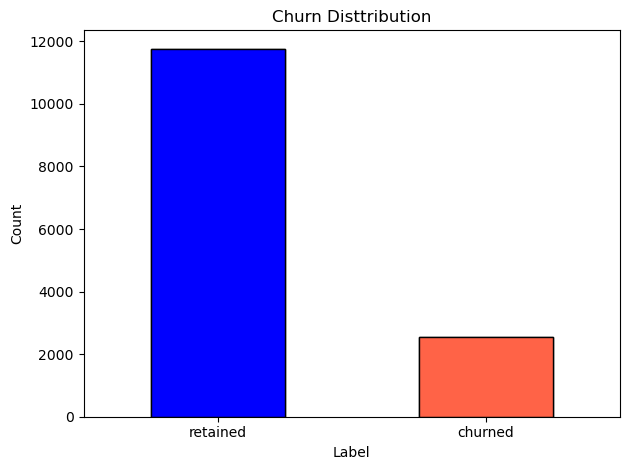

In [77]:
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

df["label"].value_counts().plot(kind='bar', color=['blue', 'tomato'], edgecolor ='black')
df['label'].value_counts().plot(kind='bar', color=['blue', 'tomato'], edgecolor='black')
plt.title("Churn Disttribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

          sessions  drives  total_sessions  driven_km_drives  \
label                                                          
churned       59.0    50.0      164.339042       3652.655666   
retained      56.0    47.0      157.586756       3464.684614   

          duration_minutes_drives  activity_days  driving_days  
label                                                           
churned               1607.183785            8.0           6.0  
retained              1458.046141           17.0          14.0  


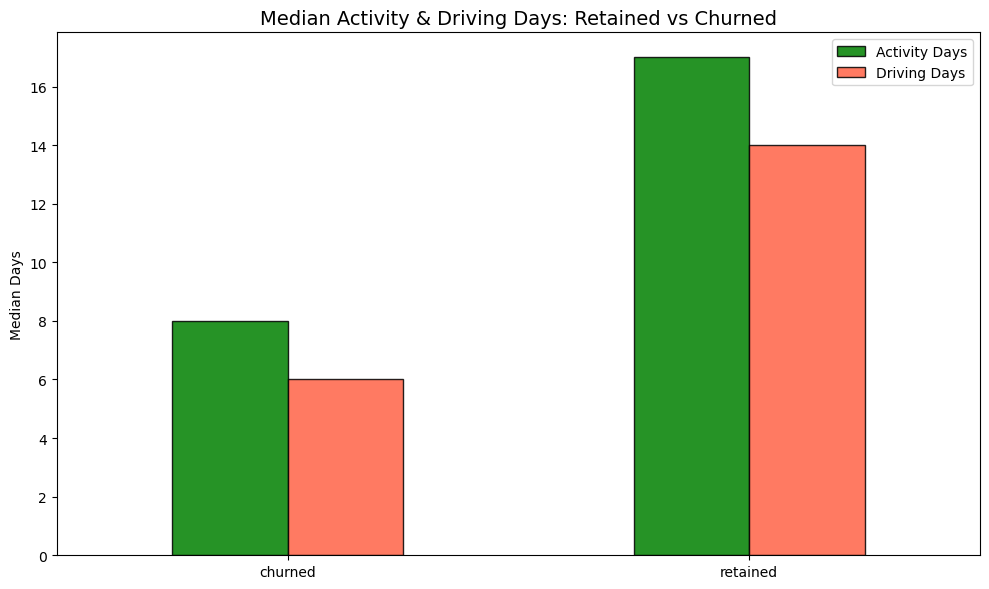

In [ ]:
#Median comparison: churned vs retained
churn_compare = df.groupby('label')[[
    'sessions', 'drives', 'total_sessions',
    'driven_km_drives', 'duration_minutes_drives',
    'activity_days', 'driving_days'
]].median()

print(churn_compare)

churn_compare[['activity_days', 'driving_days']].plot(
    kind='bar', 
    figsize=(10, 6),
    color=['green', 'tomato'],
    edgecolor='black',
    alpha=0.85
)
plt.title('Median Activity & Driving Days: Retained vs Churned', fontsize=14)
plt.ylabel('Median Days')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(['Activity Days', 'Driving Days'])
plt.tight_layout()
plt.show()


In [27]:
# Skewness scores for all numeric features
skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print("Skewness scores:")
print(skewness.round(2))

print("\nHighly skewed features (|skew| > 1):")
print(skewness[abs(skewness) > 1])

Skewness scores:
total_navigations_fav2     2.42
sessions                   2.02
drives                     1.98
total_navigations_fav1     1.97
duration_minutes_drives    1.76
total_sessions             1.48
driven_km_drives           1.30
driving_days               0.09
n_days_after_onboarding   -0.00
ID                        -0.00
activity_days             -0.01
dtype: float64

Highly skewed features (|skew| > 1):
total_navigations_fav2     2.417605
sessions                   2.019504
drives                     1.982247
total_navigations_fav1     1.966499
duration_minutes_drives    1.763430
total_sessions             1.482570
driven_km_drives           1.303516
dtype: float64


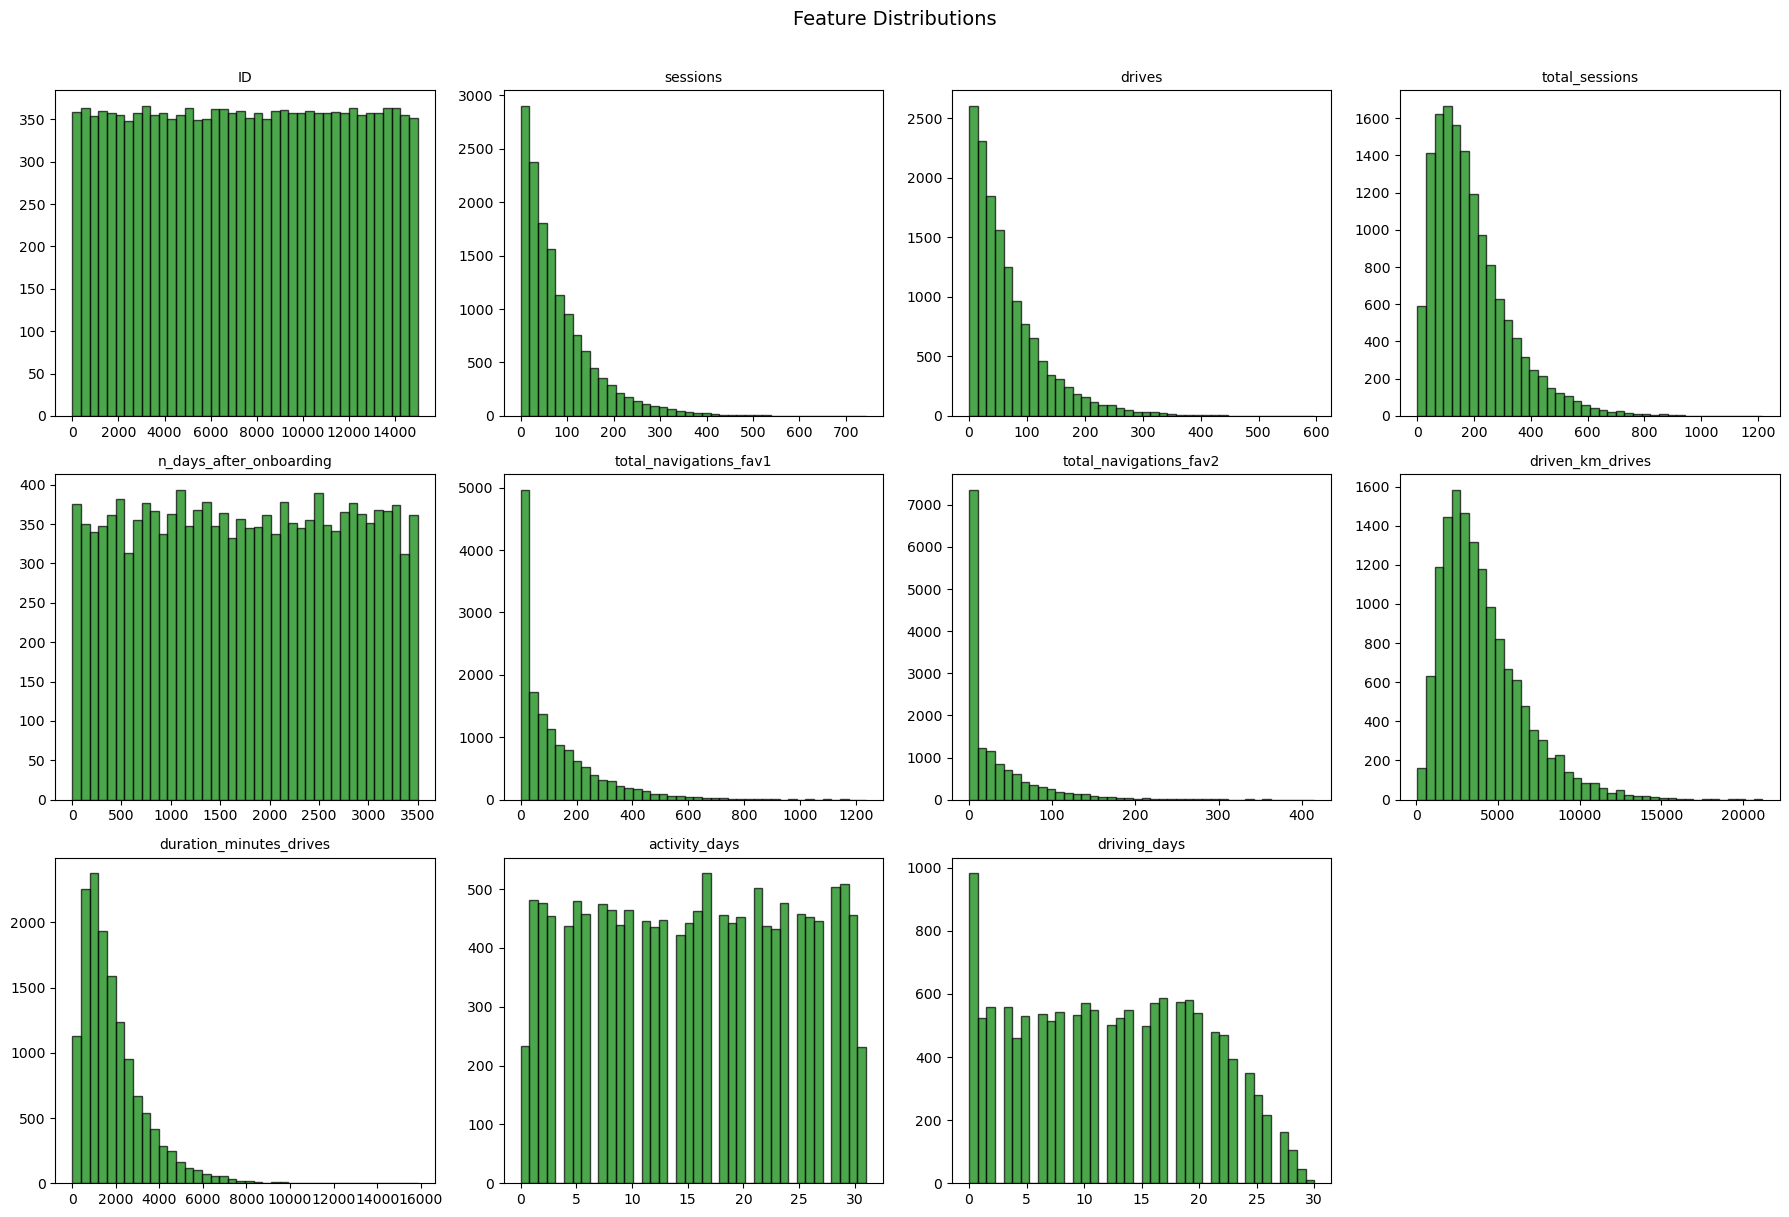

In [28]:
# visualize skewed feature distributions. Histogram

numeric_cols = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='green', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')


for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

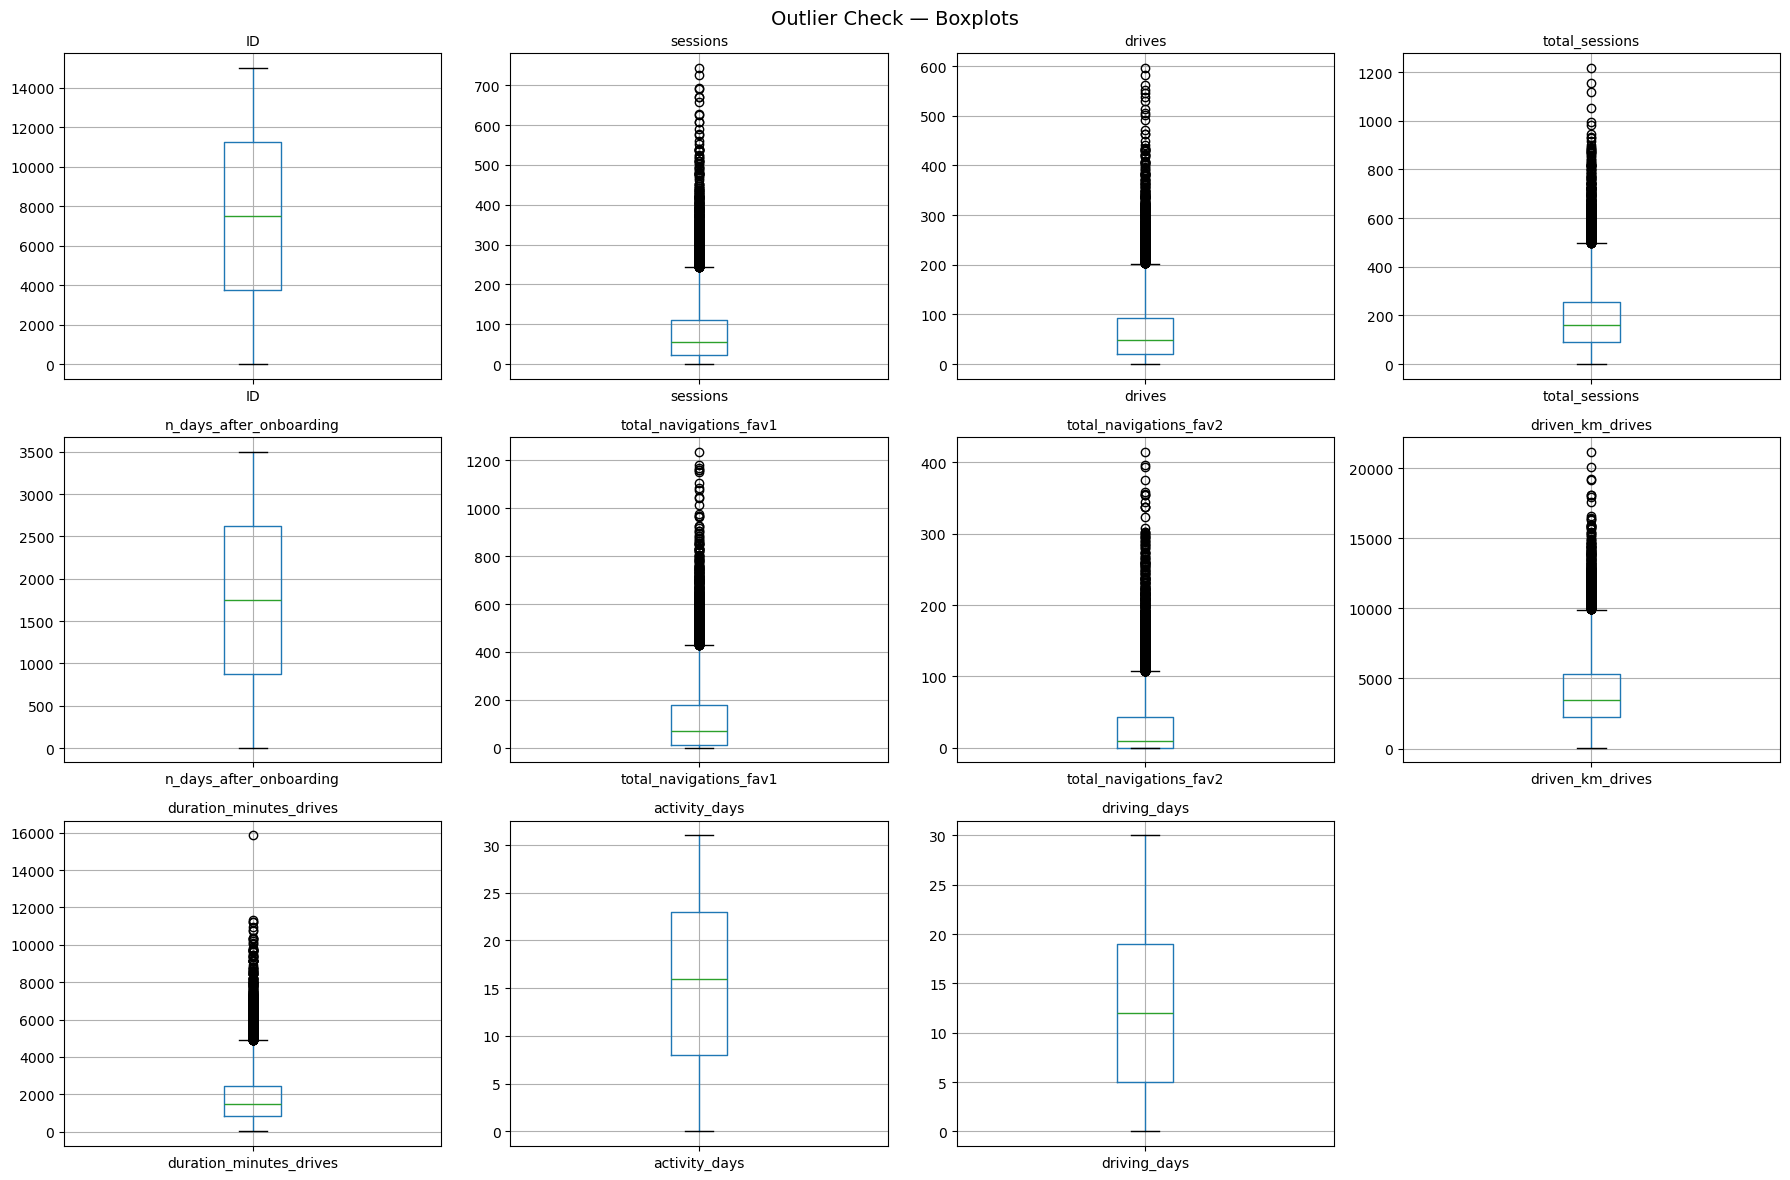

In [29]:
# visualize skewed feature distributions. Boxplot
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Check — Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

Skewness AFTER log transform:
total_navigations_fav2_log     0.11
sessions_log                  -0.71
drives_log                    -0.69
total_navigations_fav1_log    -0.72
duration_minutes_drives_log   -0.56
total_sessions_log            -0.72
driven_km_drives_log          -0.50
dtype: float64


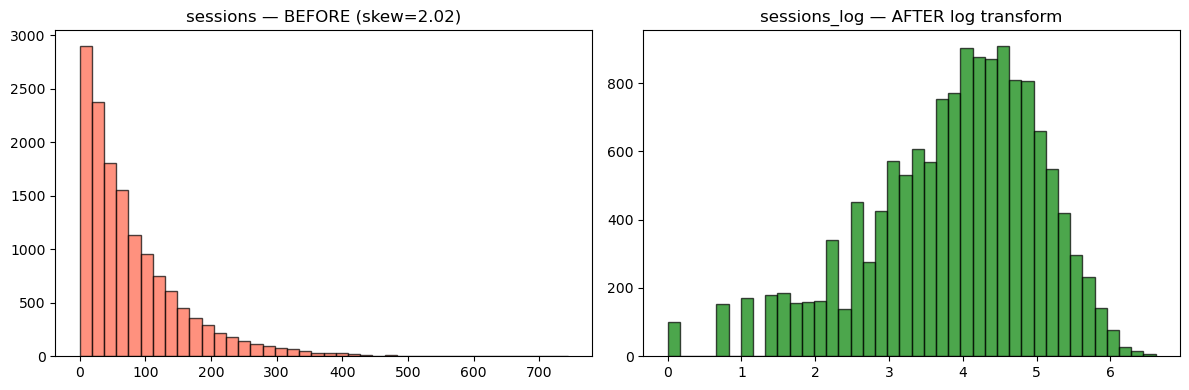

In [30]:
skewed_features = [
    'total_navigations_fav2', 'sessions', 'drives',
    'total_navigations_fav1', 'duration_minutes_drives',
    'total_sessions', 'driven_km_drives'
]

df_model = df.copy()

# Log transform 
for feat in skewed_features:
    df_model[f'{feat}_log'] = np.log1p(df_model[feat])

#skewness improved
log_features = [f'{f}_log' for f in skewed_features]
print("Skewness AFTER log transform:")
print(df_model[log_features].skew().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['sessions'], bins=40, color='tomato', edgecolor='black', alpha=0.7)
axes[0].set_title('sessions — BEFORE (skew=2.02)')

axes[1].hist(df_model['sessions_log'], bins=40, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('sessions_log — AFTER log transform')

plt.tight_layout()
plt.show()

In [38]:
# Only cap for Logistic Regression pipeline

df_lr = df.copy()  # separate copy for logistic regression
for col in ['sessions', 'drives', 'total_sessions', 'driven_km_drives', 'duration_minutes_drives']:
    upper_limit = df_lr[col].quantile(0.95)
    df_lr.loc[df_lr[col] > upper_limit, col] = upper_limit

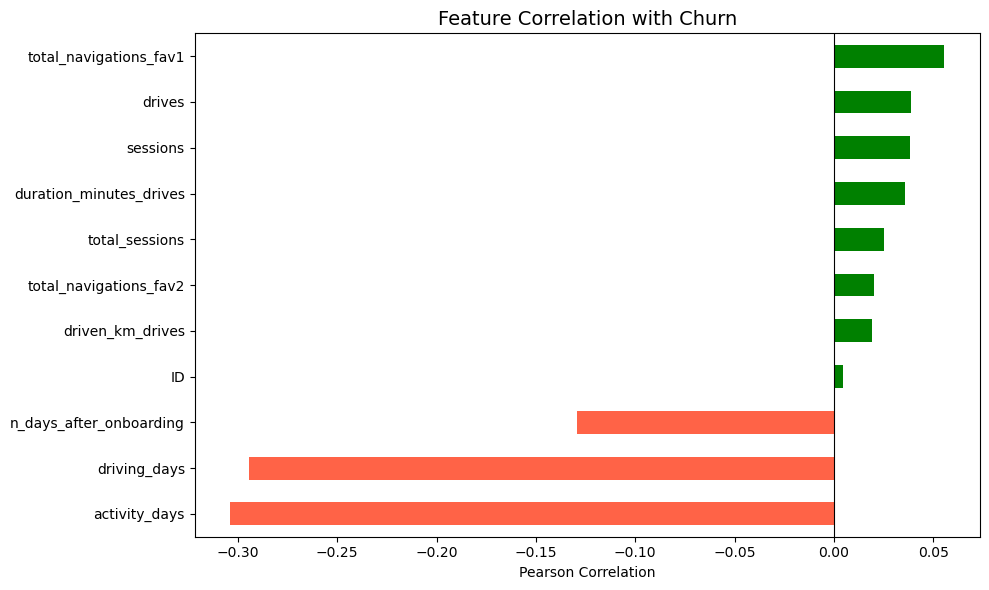

activity_days             -0.304
driving_days              -0.294
n_days_after_onboarding   -0.129
ID                         0.004
driven_km_drives           0.019
total_navigations_fav2     0.020
total_sessions             0.025
duration_minutes_drives    0.036
sessions                   0.038
drives                     0.039
total_navigations_fav1     0.056
Name: label_encoded, dtype: float64


In [39]:
df_corr = df.copy()
df_corr['label_encoded'] = (df_corr['label'] == 'churned').astype(int)
df_numeric = df_corr.select_dtypes(include='number')

# Correlation with churn specifically
churn_corr = df_numeric.corr()['label_encoded'].drop('label_encoded').sort_values()

plt.figure(figsize=(10, 6))
churn_corr.plot(kind='barh', color=['tomato' if x < 0 else 'green' for x in churn_corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Churn', fontsize=14)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(churn_corr.round(3))

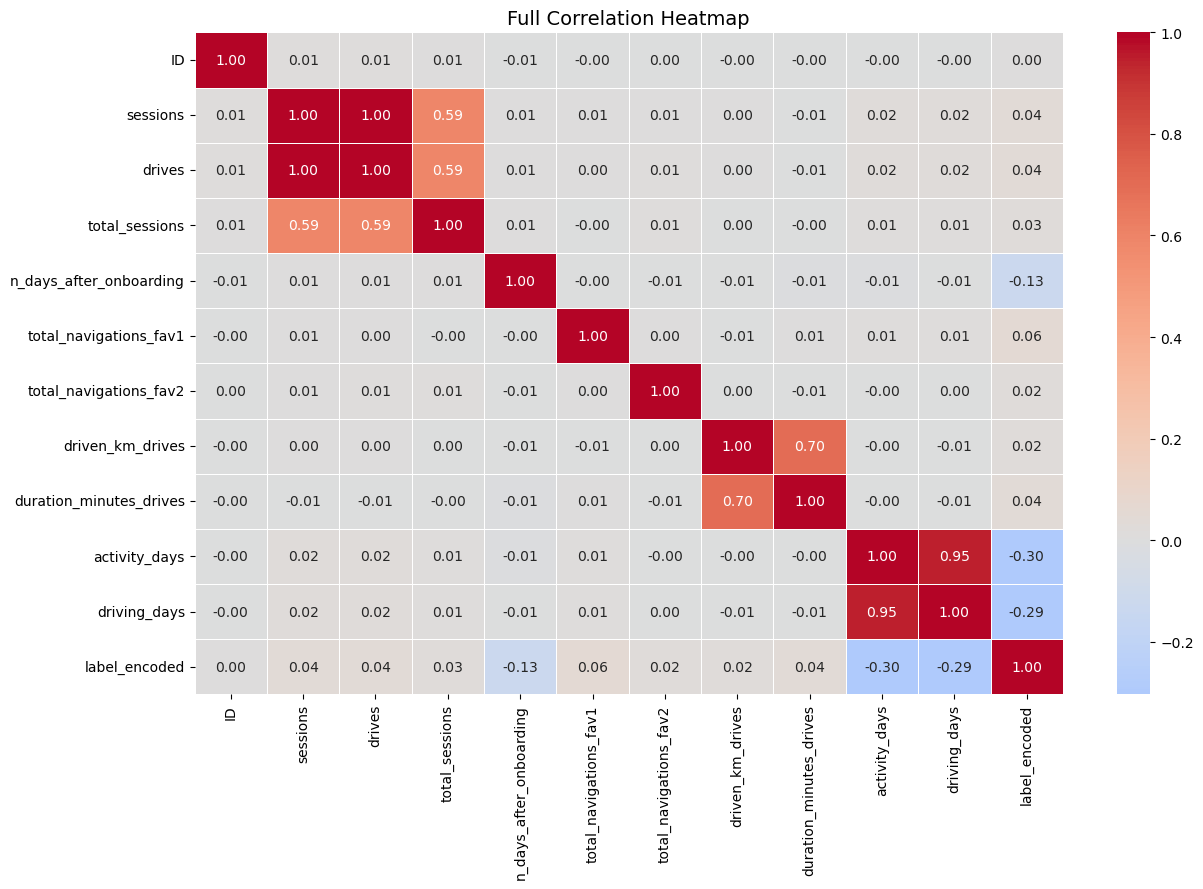

In [40]:
# Correlation heatmap
plt.figure(figsize=(13, 9))
sns.heatmap(
    df_numeric.corr(), 
    annot=True, fmt='.2f', 
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Full Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

label    churned  retained
device                    
Android    0.176     0.824
iPhone     0.178     0.822


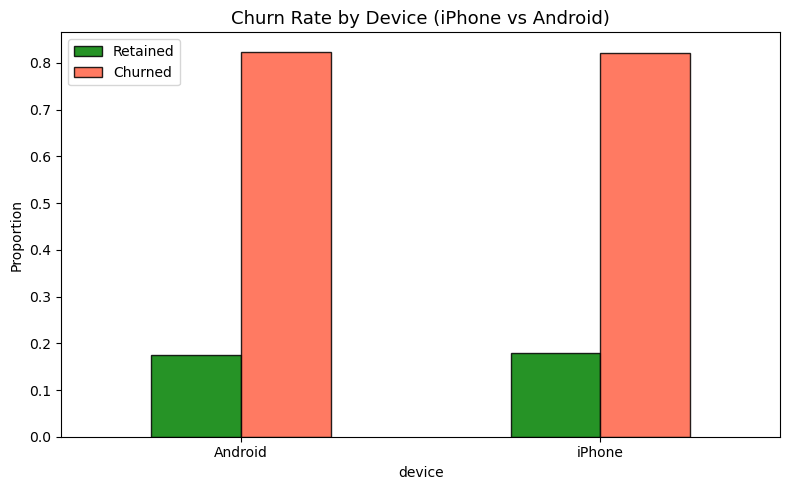


Chi-square test: χ²=0.148, p=0.7007
Device split is NOT statistically significant.


In [41]:
device_churn = df.groupby('device')['label'].value_counts(normalize=True).unstack()
print(device_churn.round(3))

device_churn.plot(
    kind='bar', 
    figsize=(8, 5),
    color=['green', 'tomato'],
    edgecolor='black',
    alpha=0.85
)
plt.title('Churn Rate by Device (iPhone vs Android)', fontsize=13)
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

# Chi-square test — is the difference statistically significant?
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['device'], df['label'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test: χ²={chi2:.3f}, p={p:.4f}")
print("Device matters for churn!" if p < 0.05 else "Device split is NOT statistically significant.")


Mutual Information Scores:
activity_days                0.0488
driving_days                 0.0463
activity_to_driving_ratio    0.0399
drives_per_day               0.0356
sessions_per_day             0.0336
percent_days_driving         0.0285
n_days_after_onboarding      0.0060
total_sessions               0.0056
duration_minutes_drives      0.0034
total_favs                   0.0026
total_navigations_fav1       0.0015
is_new_user                  0.0006
drives                       0.0006
km_per_drive                 0.0002
km_per_hour                  0.0000
driven_km_drives             0.0000
recency_ratio                0.0000
total_navigations_fav2       0.0000
fav_per_drive                0.0000
sessions                     0.0000
Name: MI Score, dtype: float64


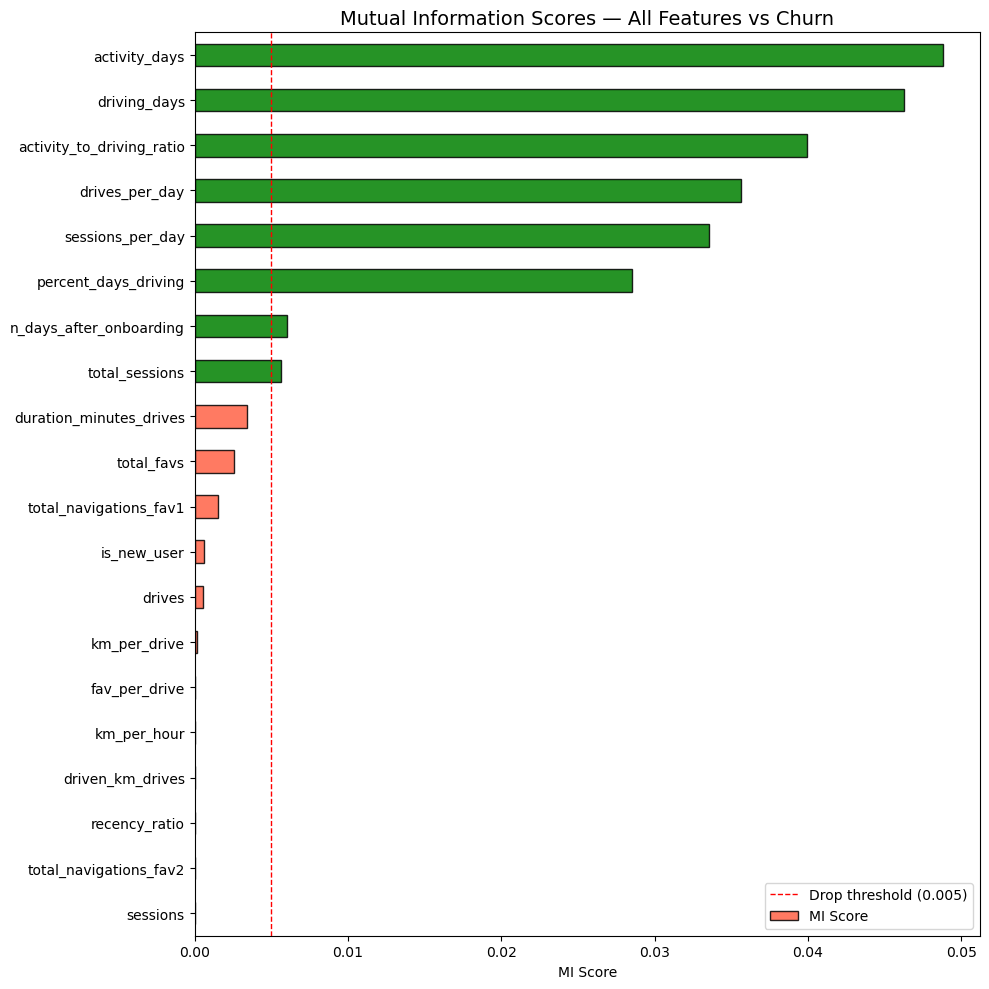


Features above threshold:
activity_days                0.0488
driving_days                 0.0463
activity_to_driving_ratio    0.0399
drives_per_day               0.0356
sessions_per_day             0.0336
percent_days_driving         0.0285
n_days_after_onboarding      0.0060
total_sessions               0.0056
Name: MI Score, dtype: float64

Features to consider dropping:
duration_minutes_drives    0.0034
total_favs                 0.0026
total_navigations_fav1     0.0015
is_new_user                0.0006
drives                     0.0006
km_per_drive               0.0002
km_per_hour                0.0000
driven_km_drives           0.0000
recency_ratio              0.0000
total_navigations_fav2     0.0000
fav_per_drive              0.0000
sessions                   0.0000
Name: MI Score, dtype: float64
Device dummy column: device_iPhone


In [42]:
# FEATURE ENGINEERING

df_fe = df.copy()

def safe_divide(num, denom):
    result = num / denom
    result.replace([np.inf, -np.inf], np.nan, inplace=True)
    result.fillna(0, inplace=True)
    return result

df_fe['km_per_drive'] = safe_divide(df_fe['driven_km_drives'], df_fe['drives'])
df_fe['km_per_hour'] = safe_divide(df_fe['driven_km_drives'], df_fe['duration_minutes_drives'] / 60)
df_fe['drives_per_day'] = safe_divide(df_fe['drives'], df_fe['activity_days'])
df_fe['sessions_per_day'] = safe_divide(df_fe['sessions'], df_fe['activity_days'])
df_fe['percent_days_driving'] = safe_divide(df_fe['driving_days'], df_fe['activity_days'])
df_fe['activity_to_driving_ratio'] = safe_divide(df_fe['activity_days'], df_fe['driving_days'])
df_fe['recency_ratio'] = safe_divide(df_fe['sessions'], df_fe['total_sessions'])
df_fe['total_favs'] = df_fe['total_navigations_fav1'] + df_fe['total_navigations_fav2']
df_fe['fav_per_drive'] = safe_divide(df_fe['total_favs'], df_fe['drives'])
df_fe['is_new_user'] = (df_fe['n_days_after_onboarding'] < 90).astype(int)

# MUTUAL INFORMATION

X_mi = df_fe.copy()
y_mi = (X_mi.pop('label') == 'churned').astype(int)
X_mi = X_mi.drop(columns=['ID'], errors='ignore')

device_dummies_mi = pd.get_dummies(X_mi['device'], prefix='device', drop_first=True)
X_mi = pd.concat([X_mi.drop(columns=['device']), device_dummies_mi], axis=1)
X_mi = X_mi.select_dtypes(include='number')

truly_discrete = ['is_new_user'] + [c for c in X_mi.columns if c.startswith('device_')]
discrete_features = [col in truly_discrete for col in X_mi.columns]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=discrete_features, random_state=42)
mi_scores = pd.Series(mi_scores, name='MI Score', index=X_mi.columns).sort_values(ascending=False)

print("\nMutual Information Scores:")
print(mi_scores.round(4))

plt.figure(figsize=(10, 10))
mi_scores.sort_values().plot(
kind='barh',
color=['tomato' if s < 0.005 else 'g' for s in mi_scores.sort_values()],
edgecolor='black',
alpha=0.85
)
plt.axvline(0.005, color='red', linestyle='--', linewidth=1, label='Drop threshold (0.005)')
plt.title('Mutual Information Scores — All Features vs Churn', fontsize=14)
plt.xlabel('MI Score')
plt.legend()
plt.tight_layout()
plt.show()

print("\nFeatures above threshold:")
print(mi_scores[mi_scores > 0.005].round(4))
print("\nFeatures to consider dropping:")
print(mi_scores[mi_scores <= 0.005].round(4))

device_dummies = pd.get_dummies(df_fe['device'], prefix='device', drop_first=True)
df_fe = pd.concat([df_fe, device_dummies], axis=1)
device_col = device_dummies.columns[0]
print(f"Device dummy column: {device_col}")

In [59]:
# FINAL FEATURE SET
features_to_keep = [
'activity_days',
'driving_days',
'activity_to_driving_ratio',
'drives_per_day',
'sessions_per_day',
'percent_days_driving',
'n_days_after_onboarding',
'total_sessions',
'duration_minutes_drives',
'km_per_drive',
device_col
]

In [60]:


def evaluate_model(model_name, y_true, y_pred, y_probs, color_map='Blues'):
    """Evaluate model and print classification metrics"""
    print(f"\n{'=' * 50}")
    print(f"{model_name} EVALUATION")
    print(f"{'=' * 50}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
    disp.plot(cmap=color_map)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

    roc_auc = roc_auc_score(y_true, y_probs)
    print(f"\nROC-AUC Score: {roc_auc:.4f}")

    pr_auc = average_precision_score(y_true, y_probs)
    print(f"Precision-Recall AUC: {pr_auc:.4f}")

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nPrecision (Churn): {precision:.4f}")
    print(f"Recall (Churn): {recall:.4f}")
    print(f"F1 Score (Churn): {f1:.4f}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

    return roc_auc, pr_auc


def best_threshold(y_true, y_probs):
    """Find optimal threshold using Youden's J statistic"""
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    youden_j = tpr - fpr
    optimal_idx = youden_j.argmax()
    return thresholds[optimal_idx]

In [61]:
# PREPARE DATA 

df_model_ready = df_fe.copy()
df_model_ready['label_binary'] = (df_model_ready['label'] == 'churned').astype(int)

X = df_model_ready[features_to_keep].copy()
y = df_model_ready['label_binary'].copy()

print(f"Null values before imputation: {X.isnull().sum().sum()}")
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f"Null values after imputation: {X.isnull().sum().sum()}")

# Train-test split (80/20 with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Null values before imputation: 0
Null values after imputation: 0

Training set size: 11439
Test set size: 2860
Training churn rate: 17.74%
Test churn rate: 17.73%


In [63]:
# SMOTE — OVERSAMPLE MINORITY CLASS (TRAINING ONLY)

print("SMOTE Oversampling")
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  { pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"Training set grew from {len(X_train)} → {len(X_train_smote)}")

SMOTE Oversampling
Before SMOTE: {0: 9410, 1: 2029}
After SMOTE:  {0: 9410, 1: 9410}
Training set grew from 11439 → 18820


In [64]:
# SCALE FEATURES

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_smote),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

# scale_pos_weight for XGBoost (still useful even with SMOTE as a secondary nudge)
scale = len(y_train_smote[y_train_smote == 0]) / len(y_train_smote[y_train_smote == 1])
print(f"\nXGBoost scale_pos_weight: {scale:.2f}")


XGBoost scale_pos_weight: 1.00



LR optimal threshold: 0.377

LOGISTIC REGRESSION (SMOTE) EVALUATION

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.53      0.67      2353
           1       0.28      0.84      0.42       507

    accuracy                           0.58      2860
   macro avg       0.61      0.68      0.54      2860
weighted avg       0.82      0.58      0.63      2860



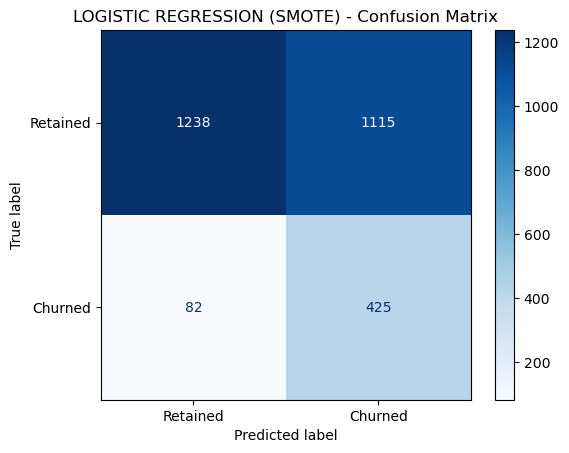


ROC-AUC Score: 0.7412
Precision-Recall AUC: 0.3802

Precision (Churn): 0.2760
Recall (Churn): 0.8383
F1 Score (Churn): 0.4152
Accuracy: 0.5815


(0.7412217061437371, 0.38021064180239506)

In [65]:
# LOGISTIC REGRESSION

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train_smote)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_thresh = best_threshold(y_test, lr_probs)
lr_preds = (lr_probs >= lr_thresh).astype(int)
print(f"\nLR optimal threshold: {lr_thresh:.3f}")
evaluate_model("LOGISTIC REGRESSION (SMOTE)", y_test, lr_preds, lr_probs, 'Blues')

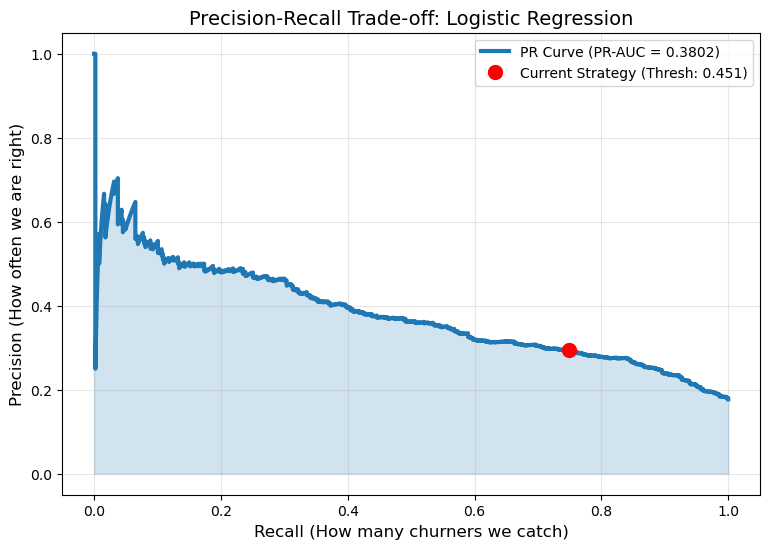

In [66]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, lr_probs)
avg_prec = average_precision_score(y_test, lr_probs)


plt.figure(figsize=(9, 6))
plt.plot(recall, precision, color='#1f77b4', lw=3, label=f'PR Curve (PR-AUC = {avg_prec:.4f})')
plt.fill_between(recall, precision, alpha=0.2, color='#1f77b4')


import numpy as np
idx = np.argmin(np.abs(thresholds - 0.451))
plt.plot(recall[idx], precision[idx], 'ro', markersize=10, label='Current Strategy (Thresh: 0.451)')


plt.title('Precision-Recall Trade-off: Logistic Regression', fontsize=14)
plt.xlabel('Recall (How many churners we catch)', fontsize=12)
plt.ylabel('Precision (How often we are right)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()



RF optimal threshold: 0.368

RANDOM FOREST EVALUATION

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.65      0.76      2353
           1       0.31      0.72      0.43       507

    accuracy                           0.66      2860
   macro avg       0.61      0.68      0.59      2860
weighted avg       0.81      0.66      0.70      2860



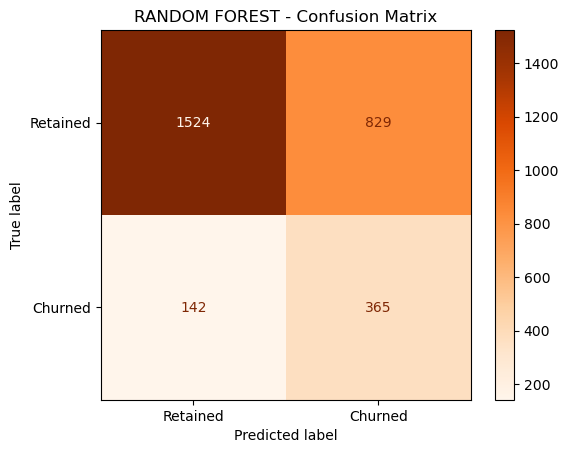


ROC-AUC Score: 0.7329
Precision-Recall AUC: 0.3592

Precision (Churn): 0.3057
Recall (Churn): 0.7199
F1 Score (Churn): 0.4292
Accuracy: 0.6605


(0.7329289647443231, 0.3591964362943133)

In [67]:
# RANDOMFOREST

rf_model = RandomForestClassifier(
n_estimators=300, 
max_depth=10, 
min_samples_split=5, 
class_weight='balanced',
random_state=42,
n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

rf_thresh = best_threshold(y_test, rf_probs)
rf_preds = (rf_probs >= rf_thresh).astype(int)
print(f"\nRF optimal threshold: {rf_thresh:.3f}")
evaluate_model("RANDOM FOREST", y_test, rf_preds, rf_probs, 'Oranges')


XGB optimal threshold: 0.180

XGBOOST EVALUATION

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.69      0.78      2353
           1       0.32      0.66      0.43       507

    accuracy                           0.69      2860
   macro avg       0.61      0.68      0.60      2860
weighted avg       0.80      0.69      0.72      2860



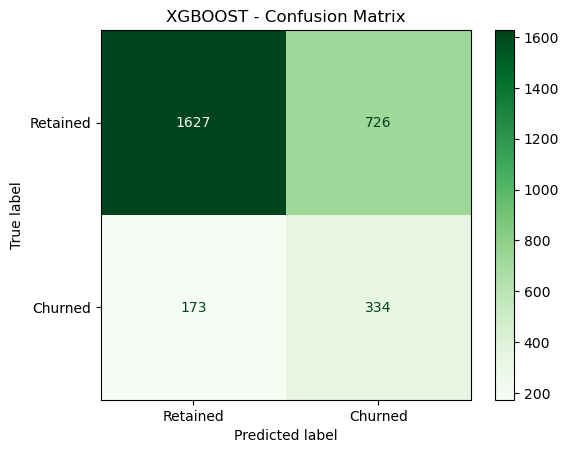


ROC-AUC Score: 0.7261
Precision-Recall AUC: 0.3469

Precision (Churn): 0.3151
Recall (Churn): 0.6588
F1 Score (Churn): 0.4263
Accuracy: 0.6857


(0.7261077595348086, 0.34690223206933446)

In [86]:
# XGBOOST

xgb_model = XGBClassifier(
n_estimators=300,
learning_rate=0.05,
max_depth=4,
scale_pos_weight=scale,
random_state=42,
eval_metric='logloss',
verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]


xgb_thresh = best_threshold(y_test, xgb_probs)
xgb_preds = (xgb_probs >= xgb_thresh).astype(int)
print(f"\nXGB optimal threshold: {xgb_thresh:.3f}")
evaluate_model("XGBOOST", y_test, xgb_preds, xgb_probs, 'Greens')

In [78]:
#  CROSS-VALIDATION 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# IMPORTANT: SMOTE must be inside the CV loop to prevent leakage.
# imblearn's Pipeline handles this correctly.

lr_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')

rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

rf_cv_scores = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc')

xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        scale_pos_weight=scale, random_state=42,
        eval_metric='logloss', verbosity=0
    ))
])
xgb_cv_scores = cross_val_score(xgb_pipe, X_train, y_train, cv=cv, scoring='roc_auc')

print("\nCross-Validation ROC-AUC (5-fold, SMOTE in pipeline)")
print(f"LR:      {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"RF:      {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"XGBoost: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")


Cross-Validation ROC-AUC (5-fold, SMOTE in pipeline)
LR:      0.7526 ± 0.0151
RF:      0.7253 ± 0.0106
XGBoost: 0.7251 ± 0.0093



Cross-Validation ROC-AUC (5-fold, SMOTE in pipeline)
LR:      0.7526 ± 0.0151
RF:      0.7253 ± 0.0106
XGBoost: 0.7251 ± 0.0093

Loaded: 700 rows, 13 cols
Inference shape: (700, 11)

Null check:
No nulls

Threshold Sensitivity
Threshold    Churn Rate     Users Flagged
--------------------------------------
0.5          40.57%         284
0.55         35.57%         249
0.6          29.29%         205
0.65         22.14%         155
0.7          16.00%         112

INFERENCE RESULTS — 700 Unlabeled Users
Threshold used: 0.55
Predicted churners: 249
Predicted retained: 451
Predicted churn rate: 35.57%
Training churn rate: 17.74% (reference)


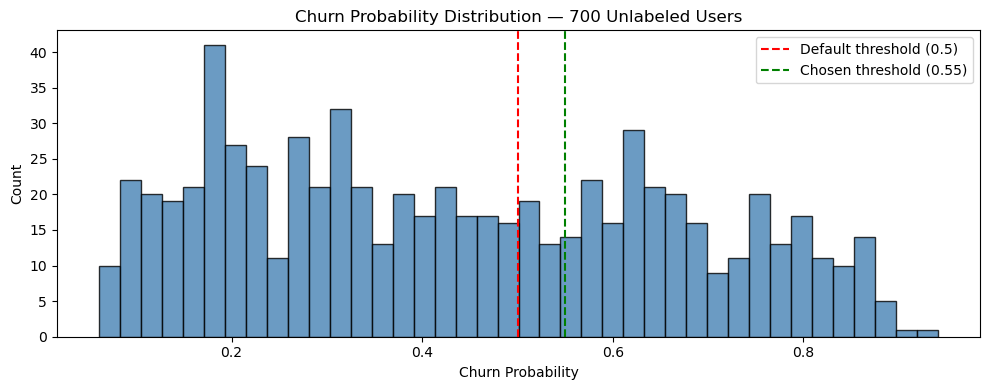


Top 20 highest churn risk:
   ID  churn_probability predicted_label
 5782           0.941314         churned
11588           0.916190         churned
  866           0.897072         churned
 8595           0.894849         churned
10994           0.893540         churned
 4490           0.888897         churned
14803           0.885619         churned
 8190           0.872094         churned
 8149           0.871926         churned
14551           0.871255         churned
13009           0.870908         churned
 4323           0.870804         churned
10920           0.869816         churned
 2846           0.869669         churned
  330           0.868948         churned
12869           0.866035         churned
14270           0.866013         churned
 7568           0.864807         churned
13289           0.858373         churned
10099           0.855201         churned

Saved → waze_inference_predictions.csv

LABELED DATA (training set):
activity_days     16.00
driving_days     

In [ ]:
# INFERENCE ON 700 UNLABELED USERS
# Best model: Logistic Regression


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# IMPORTANT: SMOTE must be inside the CV loop to prevent leakage.
# imblearn's Pipeline handles this correctly.

lr_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')

rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
rf_cv_scores = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc')

xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        scale_pos_weight=scale, random_state=42,
        eval_metric='logloss', verbosity=0
    ))
])
xgb_cv_scores = cross_val_score(xgb_pipe, X_train, y_train, cv=cv, scoring='roc_auc')

print("\nCross-Validation ROC-AUC (5-fold, SMOTE in pipeline)")
print(f"LR:      {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"RF:      {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"XGBoost: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

# INFERENCE ON 700 UNLABELED USERS


df_inference = pd.read_csv('waze_unlabeled_inference.csv')
print(f"\nLoaded: {df_inference.shape[0]} rows, {df_inference.shape[1]} cols")

df_inference['km_per_drive'] = safe_divide(df_inference['driven_km_drives'], df_inference['drives'])
df_inference['drives_per_day'] = safe_divide(df_inference['drives'], df_inference['activity_days'])
df_inference['sessions_per_day'] = safe_divide(df_inference['sessions'], df_inference['activity_days'])
df_inference['percent_days_driving'] = safe_divide(df_inference['driving_days'], df_inference['activity_days'])
df_inference['activity_to_driving_ratio'] = safe_divide(df_inference['activity_days'], df_inference['driving_days'])

device_dummies_inf = pd.get_dummies(df_inference['device'], prefix='device')
df_inference = pd.concat([df_inference, device_dummies_inf], axis=1)


for col in features_to_keep:
    if col not in df_inference.columns:
        df_inference[col] = 0

X_inference = df_inference[features_to_keep].copy()

# Impute any NaNs the same way as training
X_inference = pd.DataFrame(
    imputer.transform(X_inference),
    columns=X_inference.columns
)

print(f"Inference shape: {X_inference.shape}")  # should be (700, 11)
print(f"\nNull check:")
nulls = X_inference.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "No nulls")

X_inference_scaled = pd.DataFrame(
    scaler.transform(X_inference),
    columns=X_inference.columns
)

inference_probs = lr_model.predict_proba(X_inference_scaled)[:, 1]

# THRESHOLD SENSITIVITY
print("\nThreshold Sensitivity")
print(f"{'Threshold':<12} {'Churn Rate':<14} {'Users Flagged'}")
print("-" * 38)
for threshold in [0.50, 0.55, 0.60, 0.65, 0.70]:
    adjusted = (inference_probs >= threshold).astype(int)
    print(f"{threshold:<12} {adjusted.mean():.2%}{'':8} {adjusted.sum()}")

FINAL_THRESHOLD = 0.55  # adjustable after seeing sensitivity output

inference_preds = (inference_probs >= FINAL_THRESHOLD).astype(int)

df_inference['churn_probability'] = inference_probs
df_inference['predicted_label'] = ['churned' if p == 1 else 'retained' for p in inference_preds]

print(f"\n{'=' * 40}")
print(f"INFERENCE RESULTS — 700 Unlabeled Users")
print(f"Threshold used: {FINAL_THRESHOLD}")
print(f"{'=' * 40}")
print(f"Predicted churners: {(inference_preds == 1).sum()}")
print(f"Predicted retained: {(inference_preds == 0).sum()}")
print(f"Predicted churn rate: {inference_preds.mean():.2%}")
print(f"Training churn rate: 17.74% (reference)")

plt.figure(figsize=(10, 4))
plt.hist(inference_probs, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Default threshold (0.5)')
plt.axvline(FINAL_THRESHOLD, color='green', linestyle='--', linewidth=1.5,
            label=f'Chosen threshold ({FINAL_THRESHOLD})')
plt.title('Churn Probability Distribution — 700 Unlabeled Users')
plt.xlabel('Churn Probability')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# Top 20 highest risk users
print("\nTop 20 highest churn risk:")
print(df_inference[['ID', 'churn_probability', 'predicted_label']]
      .sort_values('churn_probability', ascending=False)
      .head(20)
      .to_string(index=False))

output_path = 'waze_inference_predictions.csv'
df_inference[['ID', 'churn_probability', 'predicted_label']].to_csv(output_path, index=False)
print(f"\nSaved → {output_path}")

# Compare feature distributions: labeled vs unlabeled
print("\nLABELED DATA (training set):")
print(df_fe[['activity_days', 'driving_days', 'drives_per_day']].median().round(2))

print("\nUNLABELED DATA (700 users):")
print(df_inference[['activity_days', 'driving_days', 'drives_per_day']].median().round(2))

In [80]:
# Compare feature distributions: labeled vs unlabeled
print("LABELED DATA (training set):")
print(df_fe[['activity_days', 'driving_days', 'drives_per_day']].median().round(2))

print("\nUNLABELED DATA (700 users):")
print(df_inference[['activity_days', 'driving_days', 'drives_per_day']].median().round(2))

LABELED DATA (training set):
activity_days     16.00
driving_days      12.00
drives_per_day     3.33
dtype: float64

UNLABELED DATA (700 users):
activity_days     15.0
driving_days      12.0
drives_per_day     3.3
dtype: float64


In [81]:
# Save original splits
X_train_orig       = X_train.copy()
X_test_orig        = X_test.copy()
y_train_orig       = y_train.copy()
y_test_orig        = y_test.copy()

X_train_scaled_orig = X_train_scaled.copy()
X_test_scaled_orig  = X_test_scaled.copy()

# Save original model
lr_model_orig  = lr_model
rf_model_orig  = rf_model
xgb_model_orig = xgb_model

# Save original scores
lr_probs_orig  = lr_probs.copy()
lr_preds_orig  = lr_preds.copy()

print(f"Original train size: {X_train_orig.shape[0]}")
print(f"Original test size:  {X_test_orig.shape[0]}")

Original train size: 11439
Original test size:  2860


In [83]:
# SELF-TRAINING — Generate pseudo-labels from v1 model

HIGH_CONF_THRESHOLD = 0.70
LOW_CONF_THRESHOLD  = 0.30

confident_mask = (inference_probs >= HIGH_CONF_THRESHOLD) | \
                 (inference_probs <= LOW_CONF_THRESHOLD)

df_confident = df_inference[confident_mask].copy()
df_confident['label'] = [
    'churned' if p >= HIGH_CONF_THRESHOLD else 'retained'
    for p in df_confident['churn_probability']
]

print(f"High-confidence predictions selected: {confident_mask.sum()} / {len(df_inference)}")
print(df_confident['label'].value_counts())


# COMBINE original + pseudo-labeled data
df_combined = pd.concat([df_fe, df_confident], ignore_index=True)

print(f"\nOriginal dataset : {len(df_fe):>5} rows")
print(f"Pseudo-labels    : {len(df_confident):>5} rows")
print(f"Combined dataset : {len(df_combined):>5} rows")


#  REBUILD FEATURES & SPLIT for v2
X_combined = df_combined[features_to_keep].copy()
y_combined  = (df_combined['label'] == 'churned').astype(int)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_combined, y_combined,
    test_size=0.2,
    random_state=42,
    stratify=y_combined
)


scaler_v2 = StandardScaler()
X_train_v2_scaled = pd.DataFrame(
    scaler_v2.fit_transform(X_train_v2),
    columns=X_train_v2.columns
)
X_test_v2_scaled = pd.DataFrame(
    scaler_v2.transform(X_test_v2),
    columns=X_test_v2.columns
)



# STEP 4: TRAIN v2 MODEL

lr_model_v2 = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model_v2.fit(X_train_v2_scaled, y_train_v2)

lr_v2_probs = lr_model_v2.predict_proba(X_test_v2_scaled)[:, 1]


lr_v2_thresh = best_threshold(y_test_v2, lr_v2_probs)
lr_v2_preds  = (lr_v2_probs >= lr_v2_thresh).astype(int)

print(f"LR v2 optimal threshold: {lr_v2_thresh:.3f}")


# STEP 5: COMPARE v1 vs v2
v1_auc = roc_auc_score(y_test_orig, lr_probs_orig)
v2_auc = roc_auc_score(y_test_v2,   lr_v2_probs)

v1_f1  = f1_score(y_test_orig, lr_preds_orig)
v2_f1  = f1_score(y_test_v2,   lr_v2_preds)

v1_rec = classification_report(y_test_orig, lr_preds_orig, output_dict=True)['1']['recall']
v2_rec = classification_report(y_test_v2,   lr_v2_preds,  output_dict=True)['1']['recall']

print("\n" + "="*58)
print("  MODEL COMPARISON — v1 (original) vs v2 (self-trained)")
print("="*58)
print(f"{'Metric':<22} {'v1':>8} {'v2':>8} {'Change':>10}")
print(f"{'Threshold':<22} {lr_thresh:>8.3f} {lr_v2_thresh:>8.3f}")
print("-"*58)
print(f"{'ROC-AUC':<22} {v1_auc:>8.4f} {v2_auc:>8.4f} {v2_auc - v1_auc:>+10.4f}")
print(f"{'F1 (Churn)':<22} {v1_f1:>8.4f} {v2_f1:>8.4f} {v2_f1  - v1_f1:>+10.4f}")
print(f"{'Recall (Churn)':<22} {v1_rec:>8.4f} {v2_rec:>8.4f} {v2_rec - v1_rec:>+10.4f}")
print("="*58)

High-confidence predictions selected: 353 / 700
label
retained    241
churned     112
Name: count, dtype: int64

Original dataset : 14299 rows
Pseudo-labels    :   353 rows
Combined dataset : 14652 rows
LR v2 optimal threshold: 0.459

  MODEL COMPARISON — v1 (original) vs v2 (self-trained)
Metric                       v1       v2     Change
Threshold                 0.377    0.459
----------------------------------------------------------
ROC-AUC                  0.7412   0.7620    +0.0208
F1 (Churn)               0.4152   0.4455    +0.0303
Recall (Churn)           0.8383   0.7717    -0.0666


c:\Users\HP\miniconda3\envs\dl_new\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


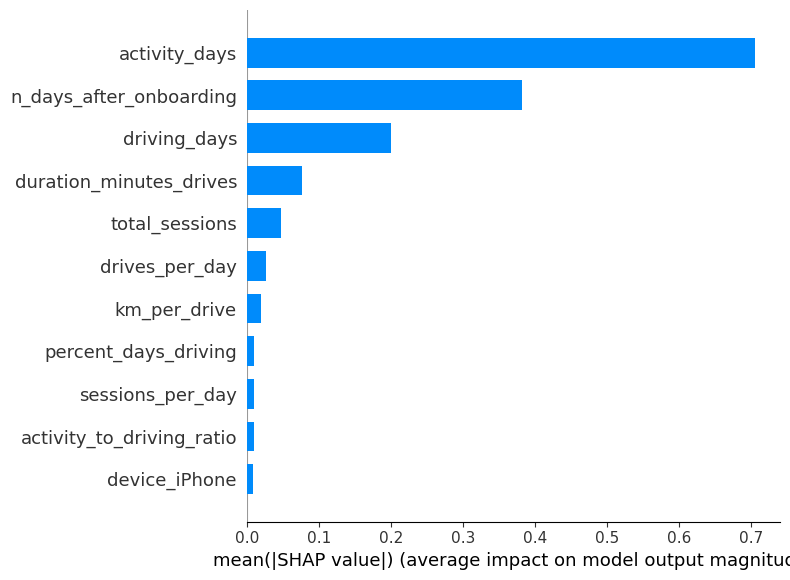

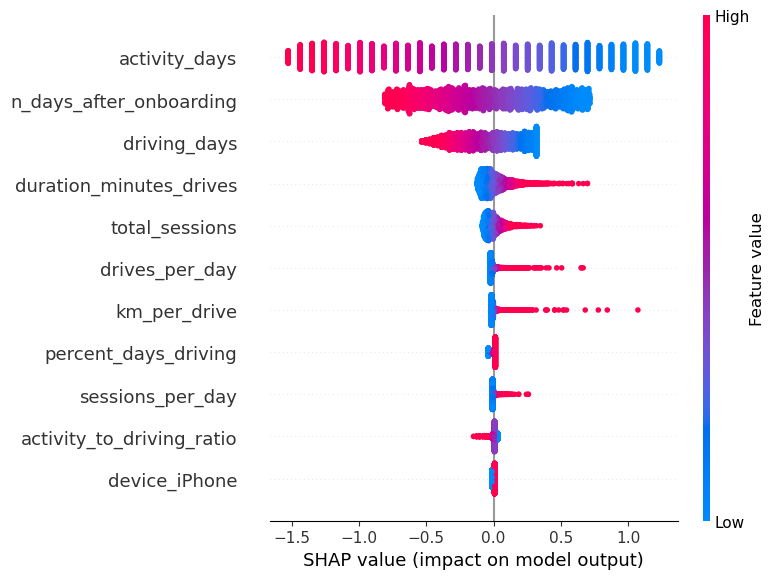

Explaining highest risk user (churn prob: 93.98%)


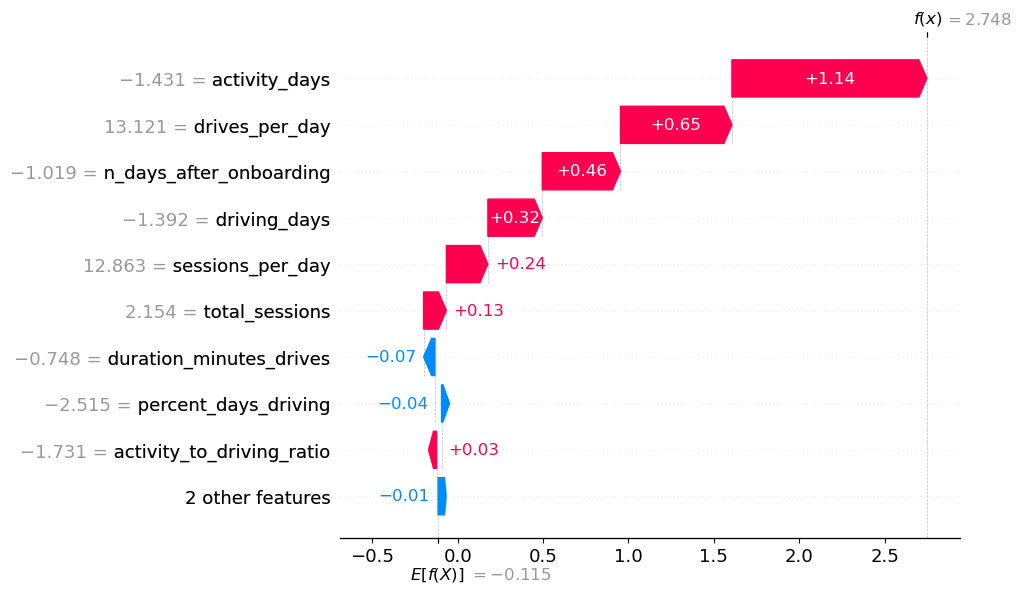

In [84]:
# SHAP — Logistic Regression (winner)

explainer = shap.LinearExplainer(lr_model, X_train_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_scaled)

# 1. Summary plot 
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    feature_names=features_to_keep,
    plot_type='bar',
    show=True
)

# 2. Beeswarm plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=features_to_keep,
    show=True
)

# 3. Single user explanation — highest risk churner
highest_risk_idx = lr_probs.argmax()
print(f"Explaining highest risk user (churn prob: {lr_probs[highest_risk_idx]:.2%})")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled.iloc[highest_risk_idx],
        feature_names=features_to_keep
    )
)

In [85]:
import joblib
import json

# Save model + scaler + features
joblib.dump(lr_model, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')

with open('features.json', 'w') as f:
    json.dump({
        'features': features_to_keep,
        'device_col': device_col,
        'threshold': lr_thresh
    }, f, indent=2)

print("Saved: model.joblib, scaler.joblib, features.json")
print(f"   Threshold: {lr_thresh:.3f}")
print(f"   Features: {len(features_to_keep)}")

Saved: model.joblib, scaler.joblib, features.json
   Threshold: 0.377
   Features: 11
